# NCh2369:2025  
## Análisis Modal Espectral en Estructuras Industriales

---

**Tema:** Aplicación del análisis dinámico según la norma chilena de diseño sísmico para instalaciones industriales.

**Autor:** MiHR  
**Contacto:** mihrsozs@gmail.com

In [102]:
#FUNCION NCh2369 2025
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#%matplotlib notebook

def NCh2369_2025(Coefimpo, Zona, Suelo, R, e, Test):    
    Tn = np.linspace(0, 5, 1001)
    g = 9.81         #Aceleración de gravedad
#---------------------------------------------------------------------------------------
    if Coefimpo == 'I': I = 0.8
    if Coefimpo == 'II': I = 1.0
    if Coefimpo == 'III': I = 1.2 
    if Coefimpo == 'IV': I = 1.2 
#---------------------------------------------------------------------------------------
    if Zona == 'Z1': Ao = 0.2*g
    if Zona == 'Z2': Ao = 0.3*g
    if Zona == 'Z3': Ao = 0.4*g   
#---------------------------------------------------------------------------------------
    if Suelo == "A": S = 0.90; r = 4.50; To = 0.15; TT = 0.15; p = 1.85; q = 3.00
    if Suelo == "B": S = 1.00; r = 4.50; To = 0.30; TT = 0.27; p = 1.60; q = 3.00
    if Suelo == "C": S = 1.05; r = 4.50; To = 0.40; TT = 0.35; p = 1.50; q = 3.00
    if Suelo == "D": S = 1.00; r = 3.50; To = 0.60; TT = 0.41; p = 1.00; q = 2.50
    if Suelo == "E": S = 1.00; r = 3.00; To = 1.20; TT = 0.79; p = 1.00; q = 2.70
#---------------------------------------------------------------------------------------  
    Ar = 1.4*Ao
    Cr = 0.16*R

    if R == 1: Rmod = 1
    elif R != 1 and Test >= Cr*TT: Rmod = R
    elif R != 1 and Test < Cr*TT: Rmod = 1.5 + (R-1.5)*(Test/(Cr*TT)); print(f'\033[38;2;255;0;0mZONA DE PERIODO CORTO R = {Rmod:.4f}\033[0m')
#---------------------------------------------------------------------------------------       
    #Espectro de referencia horizontal
    SaH = (Ar*S*((1+r*(Tn/To)**p)/(1+(Tn/To)**q)))
    #Espectro de diseño horizontal
    Sa = ((I*SaH)/Rmod)*((0.05/e)**0.4)

    #Estructura
    SaH_est = (Ar*S*((1+r*(Test/To)**p)/(1+(Test/To)**q))); Sa_est = ((I*SaH_est)/Rmod)*((0.05/e)**0.4)
#---------------------------------------------------------------------------------------            
    #Espectro de referencia vertical
    SaHv = (0.7*Ar*S*((1+r*(1.7*(Tn/To))**p)/(1+(1.7*(Tn/To))**q)))
    #Espectro de diseño vertical
    Rv = 2; ev = 0.03; Sav = ((I*SaHv)/Rv)*((0.05/ev)**0.4)
    
    #Estructura
    SaHv_est = (0.7*Ar*S*((1+r*(1.7*(Test/To))**p)/(1+(1.7*(Test/To))**q))); Sav_est = ((I*SaHv_est)/Rv)*((0.05/ev)**0.4)

    #Coeficiente sismico vertical 
    if Suelo == 'D':
        Cv = 1.1*I*Ar*S/g
    elif Suelo == 'E':
        Cv = I*Ar*S/g
    else:
        Cv = 1.2*I*Ar*S/g
#---------------------------------------------------------------------------------------            
    #Corte minimo y maximo
    Cmin = 0.25*((I*Ar*S)/g)
    Cmax = 2.75*((I*Ar*S)/(g*(R+1)))*((0.05/e)**0.4)
#---------------------------------------------------------------------------------------            
    #print(max(Sa/g))
    return Tn, SaH/g, SaHv/g, Sa/g, Sav/g, Rmod, Sa_est/g, Sav_est/g, Cmin, Cmax, Cv, Cr*TT, SaH_est/g, I

In [103]:
#FUNCION GRAFICO ESPECTRO DE DISEÑO

plt.rcParams['font.sans-serif'] = 'Times New Roman' #Times New Roman
plt.rcParams.update({'font.size': 12}) 

def graf_espec(Coefimpo,Zona,Suelo,R,e,T_est,Ps,COND):

    #NCh2369_25_R1 = NCh2369_2025(Coefimpo, Zona, Suelo, 1, e, T_est)
    NCh2369_25 = NCh2369_2025(Coefimpo, Zona, Suelo, R, e, T_est)
    print('--------------------------------------')
    print('RESUMEN:')
    print('--------------------------------------')
    print(f'Fac. de importancia:\tI = {NCh2369_25[13]}')
    print(f'Zona Sismica:\t\tZ = {Zona}')
    print(f'Tipo de Suelo:\t\tS = {Suelo}')
    print(f'Fact. mod. resp.:\tR = {R}')
    print(f'Razón de amort.:\te = {e}')
    print('--------------------------------------')
    print(f'Tn estructura:\t\tT = {T_est} seg')
    print(f'Peso sismico:\t\tPs = {Ps} kgf')
    print('--------------------------------------')
    #----------------------------------------------------------------------------------------------------
    import os
    from datetime import datetime
    if COND == True:
        fecha = datetime.today().strftime('%d%m%Y') 
        # Crear una carpeta para guardar grafico y archivo .txt
        nombre_carpeta = f'{fecha}_{Coefimpo}{Zona}S{Suelo}R{R}'
        os.makedirs(nombre_carpeta, exist_ok=True)
    #----------------------------------------------------------------------------------------------------

    plt.figure(figsize=(5.5, 4.5), dpi = 100)

    plt.grid(which="major", alpha=0.15)
    plt.minorticks_on()
    plt.grid(which="minor", alpha=0.05)

    plt.title('NCh2369 (2025)\nEspectro de diseño horizontal y vertical {}={}'.format(chr(958),e), fontsize=14, fontweight='bold') 
    plt.xlabel('T [s]', fontsize=12)
    plt.ylabel('Sa [g]', fontsize=12)

    plt.plot(NCh2369_25[0],NCh2369_25[1],'-', alpha=1, linewidth=1.5, color='k',label = f'{Coefimpo}{Zona}S{Suelo}REF') 
    plt.plot(NCh2369_25[0],NCh2369_25[3],'-', alpha=1, linewidth=1.5, color='red',label = f'{Coefimpo}{Zona}S{Suelo}R{NCh2369_25[5]:.3f}') 
    plt.plot(NCh2369_25[0],NCh2369_25[4],'-', alpha=1, linewidth=1.5, color='blue',label = f'{Coefimpo}{Zona}S{Suelo}R2v') 

    plt.plot(T_est,NCh2369_25[12],'*', alpha=1, markersize=9, color='k', label = f'{NCh2369_25[12]:.3f} g')
    plt.plot(T_est,NCh2369_25[6],'*', alpha=1, markersize=9, color='red', label = f'{NCh2369_25[6]:.3f} g') 
    plt.plot(T_est,NCh2369_25[7],'*', alpha=1, markersize=9, color='blue', label = f'{NCh2369_25[7]:.3f} g') 

    #print(f'Cmin = {NCh2369_25[8]:.4f}')
    #print(f'Cmax = {NCh2369_25[9]:.4f}')

    plt.axhline(NCh2369_25[8], color='black', linestyle='--', linewidth=0.8)
    plt.axhline(NCh2369_25[9], color='black', linestyle='--', linewidth=0.8)

    plt.axvline(NCh2369_25[11], color='black', linestyle='--', linewidth=0.8)

    #----------------------------------------------------------------------------------------------------
    if R != NCh2369_25[5]:
        #plt.text(1.89, 0.22, 'ZONA DE PERIODO CORTO',color='k', fontsize=9)
        plt.text(1.92, 0.1, f'T* < Cr*T1; Rmod = {NCh2369_25[5]:.2f}',color='k', fontsize=10, bbox=dict(facecolor='white', edgecolor='black', boxstyle='square,pad=0.5'))
    #----------------------------------------------------------------------------------------------------

    plt.xlim(0,3)
    major_ticks_top=np.linspace(0,3,7)
    plt.xticks(major_ticks_top)

    #plt.ylim(0,max(NCh2369_25_R1[3])+0.1)
    # major_ticks_top=np.linspace(0,1.8,8)
    # plt.yticks(major_ticks_top)
    plt.margins(y=0.05)

    plt.legend(loc=1, fontsize=9, ncol=1, frameon=False)#, edgecolor='black', facecolor='white', borderaxespad=1)
    plt.tight_layout()
    #plt.savefig(f'{Coefimpo}{Zona}S{Suelo}R{NCh2369_SD[5]:.0f}.jpg', dpi=800)
    if COND == True:
        plt.savefig((f"{fecha}_{Coefimpo}{Zona}S{Suelo}R{R}")+'/'+f"{Coefimpo}{Zona}S{Suelo}R{NCh2369_25[5]:.0f}.jpg", dpi=800)
    plt.show()
    
    import csv
    if COND == True:
        df = pd.DataFrame({'Tn [S]': list(NCh2369_25[0]), 'Sa [g]': list(NCh2369_25[1])})
        df.set_index(list(df)[0], inplace=True)
        df.to_csv((f"{fecha}_{Coefimpo}{Zona}S{Suelo}R{R}")+'/'+f"{Coefimpo}{Zona}S{Suelo}REF.txt", sep="\t", quoting=csv.QUOTE_NONE)

        df = pd.DataFrame({'Tn [S]': list(NCh2369_25[0]), 'Sa [g]': list(NCh2369_25[3])})
        df.set_index(list(df)[0], inplace=True)
        df.to_csv((f"{fecha}_{Coefimpo}{Zona}S{Suelo}R{R}")+'/'+f"{Coefimpo}{Zona}S{Suelo}R{NCh2369_25[5]:.2f}.txt", sep="\t", quoting=csv.QUOTE_NONE)

        df = pd.DataFrame({'Tn [S]': list(NCh2369_25[0]), 'Sa [g]': list(NCh2369_25[4])})
        df.set_index(list(df)[0], inplace=True)
        df.to_csv((f"{fecha}_{Coefimpo}{Zona}S{Suelo}R{R}")+'/'+f"{Coefimpo}{Zona}S{Suelo}R2v.txt", sep="\t", quoting=csv.QUOTE_NONE)

    #----------------------------------------------------------------------------------------------------
    #Verificación de corte minimo y maximo

    Q_estr = NCh2369_25[6]*Ps
    Qmin = NCh2369_25[8]*Ps
    Qmax = NCh2369_25[9]*Ps

    R1 = NCh2369_25[5]*min(Q_estr/Qmin,1)

    print('---------------------------------------------')
    print(f'Coef. sis. vertical:\t{NCh2369_25[10]:.3f}')
    print('---------------------------------------------')
    print(f'Corte estructura:\t{Q_estr:.3f} kgf (5.7.1)')
    print(f'Corte minimo:\t\t{Qmin:.3f} kgf (5.12)')
    print(f'Corte maximo:\t\t{Qmax:.3f} kgf (5.13)')
    print('---------------------------------------------')
    if Q_estr > Qmin and Q_estr < Qmax: FC = 1
    elif Q_estr < Qmin: FC = Qmin/Q_estr
    elif Q_estr > Qmax: FC = Qmax/Q_estr
    print(f'Factor de corrección:\t{FC:.3f}')
    #print(f'R1:\t\t\t{R1:.3f}')
    print('---------------------------------------------')
    print(f'Corte final estructura:\t{FC*Q_estr:.3f} kgf')

ZONA DE PERIODO CORTO R = 4.7407
--------------------------------------
RESUMEN:
--------------------------------------
Fac. de importancia:	I = 1.0
Zona Sismica:		Z = Z3
Tipo de Suelo:		S = B
Fact. mod. resp.:	R = 5
Razón de amort.:	e = 0.03
--------------------------------------
Tn estructura:		T = 0.2 seg
Peso sismico:		Ps = 5000 kgf
--------------------------------------


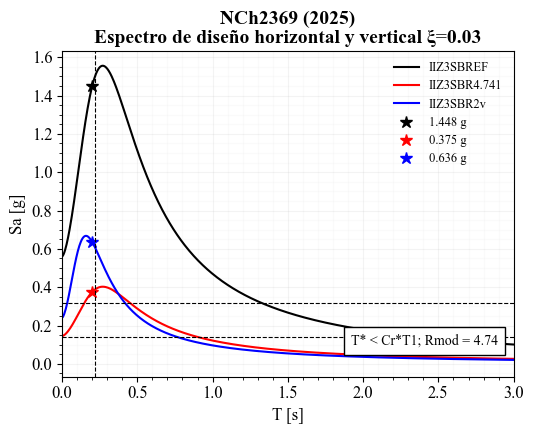

---------------------------------------------
Coef. sis. vertical:	0.672
---------------------------------------------
Corte estructura:	1873.577 kgf (5.7.1)
Corte minimo:		700.000 kgf (5.12)
Corte maximo:		1574.269 kgf (5.13)
---------------------------------------------
Factor de corrección:	0.840
---------------------------------------------
Corte final estructura:	1574.269 kgf


In [104]:
graf_espec('II','Z3','B', 5, 0.03, 0.2, 5000, True) # [kgf] True: Se crea carpeta y se guardan los archivos .jpg y .txt